In [1]:
# =============================
# Import Libraries
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

In [2]:
# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Full Model - XGBoost (Climate)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 5)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7584
Best params: {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0, 'n_estimators': 800, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 2, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.7592

Classification report:
              precision    recall  f1-score   support

        High     0.4444    0.0408    0.0748        98
         Low     0.8143    0.9307    0.8686      1183
      Medium     0.5200    0.4105    0.4588       380

    accuracy                         0.7592      1661
   macro avg     0.5929    0.4607    0.4674      1661
weighted avg     0.7252    0.7592    0.7280      1661



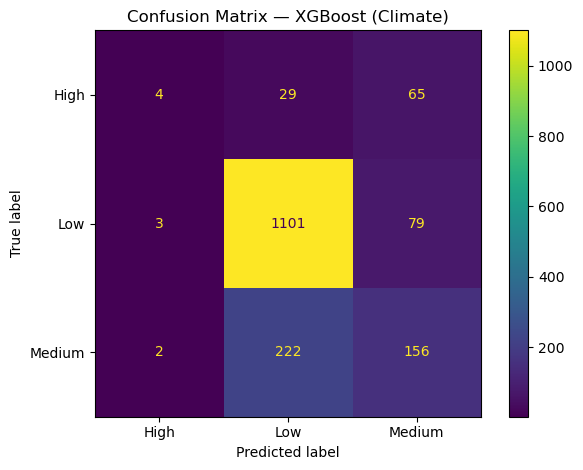

In [3]:
# ============================================================
# FULL MODEL: Climate 
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]
TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]
# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + time)
numeric_cols = [
    "Rain", "Temperature", "Relative Humidity",
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Climate)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Climate)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Socioeconomic)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7933
Best params: {'subsample': 0.85, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_weight': 4, 'max_depth': 8, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.8043

Classification report:
              precision    recall  f1-score   support

        High     0.5185    0.4286    0.4693        98
         Low     0.8688    0.9349    0.9007      1183
      Medium     0.6124    0.4947    0.5473       380

    accuracy                         0.8043      1661
   macro avg     0.6666    0.6194    0.6391      1661
weighted avg     0.7895    0.8043    0.7944      1661



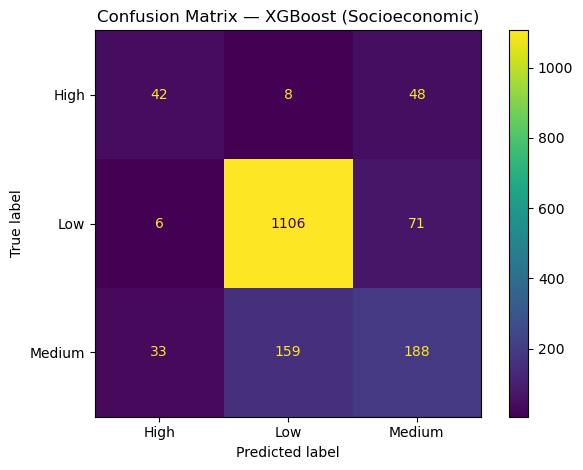

In [4]:
# ============================================================
# FULL MODEL: Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric socio columns
numeric_cols = [
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical socio columns
cat_cols = ["Municipal Class", "Settlement Type"]

for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Socioeconomic)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 11)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.8027
Best params: {'subsample': 0.75, 'reg_lambda': 0.5, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.85}

Hold-out accuracy: 0.8164

Classification report:
              precision    recall  f1-score   support

        High     0.6341    0.5306    0.5778        98
         Low     0.8783    0.9273    0.9021      1183
      Medium     0.6273    0.5447    0.5831       380

    accuracy                         0.8164      1661
   macro avg     0.7132    0.6676    0.6877      1661
weighted avg     0.8065    0.8164    0.8100      1661



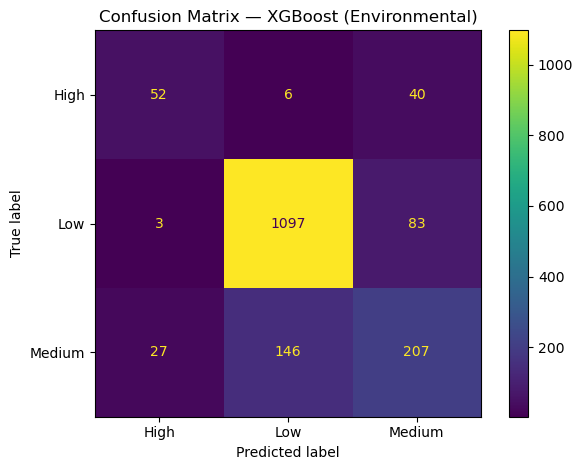

In [5]:
# ============================================================
# FULL MODEL: Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric environmental columns
numeric_cols = [
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical environmental columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Environmental)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Climate + Socioeconomic)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 17)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7801
Best params: {'subsample': 0.75, 'reg_lambda': 10.0, 'reg_alpha': 0.5, 'n_estimators': 800, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.5, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.7971

Classification report:
              precision    recall  f1-score   support

        High     0.6000    0.3061    0.4054        98
         Low     0.8424    0.9442    0.8904      1183
      Medium     0.6211    0.4658    0.5323       380

    accuracy                         0.7971      1661
   macro avg     0.6878    0.5720    0.6094      1661
weighted avg     0.7774    0.7971    0.7799      1661



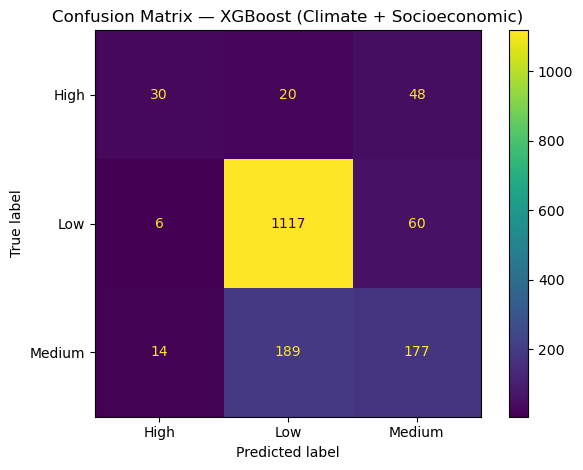

In [6]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + socio numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # socio numeric
    "Total Population", "Public Healthcare Facilities", "Private Healthcare Facilities",
    # time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical socio columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Climate + Socioeconomic)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Climate + Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Climate + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7905
Best params: {'subsample': 0.75, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 6, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.8122

Classification report:
              precision    recall  f1-score   support

        High     0.6852    0.3776    0.4868        98
         Low     0.8640    0.9400    0.9004      1183
      Medium     0.6250    0.5263    0.5714       380

    accuracy                         0.8122      1661
   macro avg     0.7247    0.6146    0.6529      1661
weighted avg     0.7988    0.8122    0.8007      1661



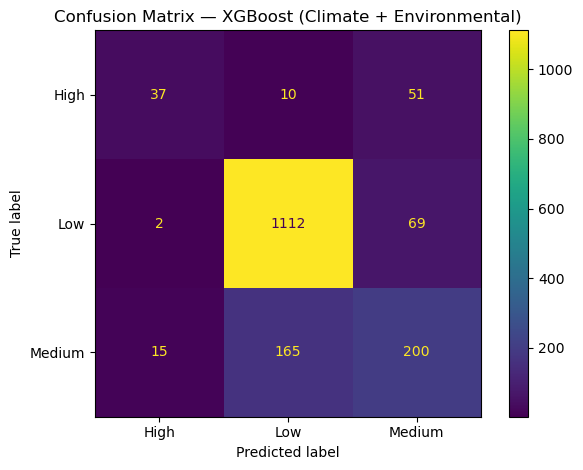

In [7]:
# ============================================================
# FULL MODEL: Climate + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + env numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # env numeric
    "Forest Cover (%)", "Agricultural Land (%)", "Water Bodies (%)",
    "Open Vegetation (%)", "Built-up / Barren (%)",
    # time
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical environmental columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Climate + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Climate + Environmental)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Socioeconomic + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 23)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.8045
Best params: {'subsample': 0.85, 'reg_lambda': 2.0, 'reg_alpha': 2.0, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}

Hold-out accuracy: 0.823

Classification report:
              precision    recall  f1-score   support

        High     0.6154    0.4898    0.5455        98
         Low     0.8808    0.9366    0.9078      1183
      Medium     0.6492    0.5553    0.5986       380

    accuracy                         0.8230      1661
   macro avg     0.7151    0.6606    0.6840      1661
weighted avg     0.8121    0.8230    0.8157      1661



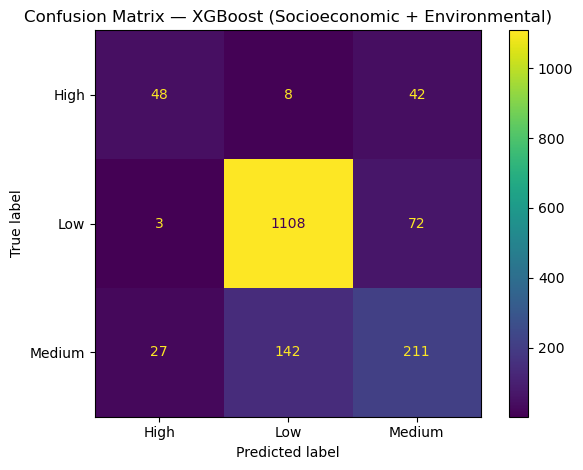

In [8]:
# ============================================================
# FULL MODEL: Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (socio numeric + env numeric + time)
numeric_cols = [
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Socioeconomic + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()

Full Model - XGBoost (Climate + Socioeconomic + Environmental)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 26)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7965
Best params: {'subsample': 0.75, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 6, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}

Hold-out accuracy: 0.8206

Classification report:
              precision    recall  f1-score   support

        High     0.7193    0.4184    0.5290        98
         Low     0.8683    0.9417    0.9035      1183
      Medium     0.6480    0.5474    0.5934       380

    accuracy                         0.8206      1661
   macro avg     0.7452    0.6358    0.6753      1661
weighted avg     0.8091    0.8206    0.8105      1661



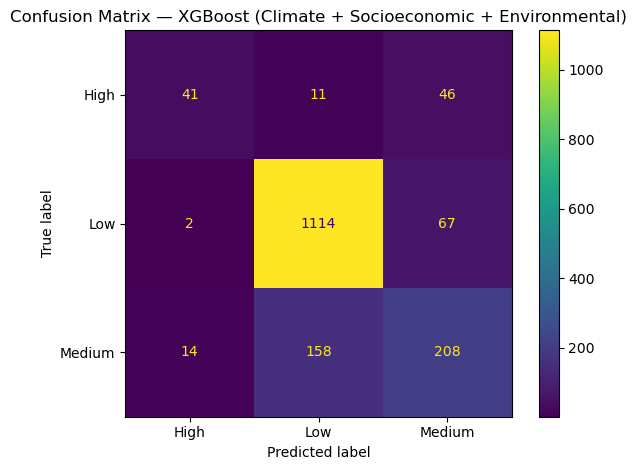

In [9]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]  # keep if you still want time; remove if not needed

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + socio numeric + env numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model - XGBoost (Climate + Socioeconomic + Environmental)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# XGBoost + Hyperparameter Tuning
# -----------------------------
objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
eval_metric = "mlogloss" if num_classes > 2 else "logloss"

base_model = XGBClassifier(
    objective=objective,
    eval_metric=eval_metric,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "max_depth": [2, 3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.6, 0.75, 0.85, 1.0],
    "colsample_bytree": [0.6, 0.75, 0.85, 1.0],
    "min_child_weight": [1, 2, 4, 6, 8, 12],
    "gamma": [0, 0.5, 1, 2, 5],
    "reg_alpha": [0, 0.1, 0.5, 1.0, 2.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — XGBoost (Climate + Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()